In [4]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR


In [5]:
df = pd.read_csv('dataset/car1.csv')
df.head()

,Car_Name,Year,selling_price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [6]:
le = LabelEncoder()
df['Car_Name'] = le.fit_transform(df['Car_Name'])
df['Fuel_Type'] = le.fit_transform(df['Fuel_Type'])
df['Seller_Type'] = le.fit_transform(df['Seller_Type'])
df['Transmission'] = le.fit_transform(df['Transmission'])


In [7]:
x = df.drop(columns='selling_price',axis=1)
y = df['selling_price']
x.head()

,Car_Name,Year,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,90,2014,5.59,27000,2,0,1,0
1,93,2013,9.54,43000,1,0,1,0
2,68,2017,9.85,6900,2,0,1,0
3,96,2011,4.15,5200,2,0,1,0
4,92,2014,6.87,42450,1,0,1,0


In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [9]:
models = {
    "Linear regression": LinearRegression(),
    "Ridge regression" : Ridge(),
    "Lasso regression" : Lasso(),
    "DecisionTree Regressor" : DecisionTreeRegressor(),
    "RandomForest Regressor" : RandomForestRegressor(),
    "GradientBoosting Regressor" : GradientBoostingRegressor(),
    "Support vector machine" : SVR()
}

In [10]:
results = {}
input_value = []
names = []
col  = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'olive']

C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(
C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\

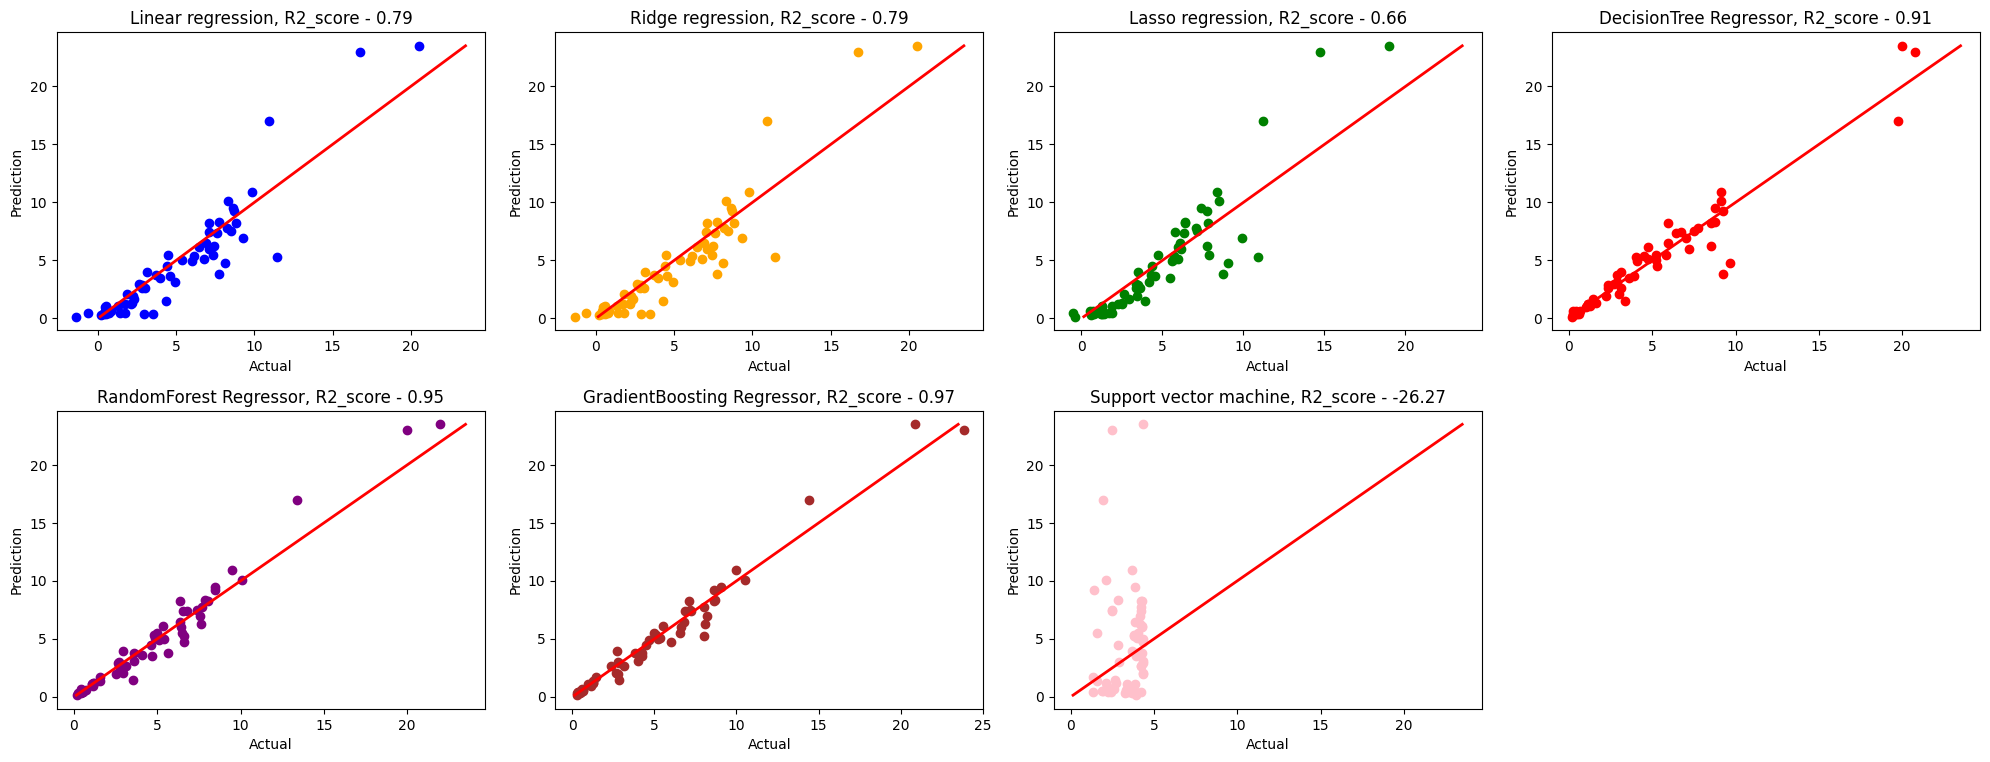

In [11]:
plt.figure(figsize=(20, 30))


for i, (name, model) in enumerate(models.items(), 1):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    mae = mean_absolute_error(y_pred, y_test)
    mse = mean_squared_error(y_pred, y_test)
    r2 = r2_score(y_pred, y_test)

    a = [[1,2012, 9.85, 9900, 0, 0, 0, 1]]
    names.append(name)
    input_value.append(model.predict(a))

    results[name] = {
        'Mean absolute error': mae,
        'Mean square error': mse,
        'R2 score': r2
    }

    plt.subplot(8, 4, i)
    plt.scatter(y_pred, y_test, color=col[i-1])
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
    plt.title(f"{name}, R2_score - {r2:.2f}")
    plt.xlabel("Actual")
    plt.ylabel("Prediction")

plt.tight_layout()
plt.show()


In [12]:
result_df = pd.DataFrame(results).T
values = pd.DataFrame(input_value).T
name_value = pd.DataFrame(names).T
print(result_df)

values.columns = name_value.iloc[0].tolist()
print(values)

                            Mean absolute error  Mean square error   R2 score
Linear regression                      1.214234           3.534719   0.788457
Ridge regression                       1.213021           3.517336   0.787799
Lasso regression                       1.433865           4.523691   0.658913
DecisionTree Regressor                 0.764754           1.805798   0.914454
RandomForest Regressor                 0.600834           0.919008   0.949896
GradientBoosting Regressor             0.532311           0.682240   0.967511
Support vector machine                 3.154526          25.229175 -26.273790
   Linear regression  Ridge regression  Lasso regression  \
0           8.869031          8.660003           4.27891   

   DecisionTree Regressor  RandomForest Regressor  GradientBoosting Regressor  \
0                     4.4                   5.097                    5.168262   

   Support vector machine  
0                2.047902  
